In [1]:
from pathlib import Path
import json
import re
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
!git clone https://github.com/Nusultan11/llm-ml-educational-assistant.git
%cd /content/llm-ml-educational-assistant
!pip install -q -r requirements.txt
!pip install -q -e .
!pip install -q pandas matplotlib seaborn

Cloning into 'llm-ml-educational-assistant'...
remote: Enumerating objects: 231, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (160/160), done.
remote: Total 231 (delta 99), reused 190 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (231/231), 194.24 KiB | 1.06 MiB/s, done.
Resolving deltas: 100% (99/99), done.
/content/llm-ml-educational-assistant
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llm-ml-assistant (pyproject.toml) ... done


In [3]:
DRIVE_ROOT = Path("/content/drive/MyDrive/llm_ml_assistant")
(DRIVE_ROOT / "artifacts").mkdir(parents=True, exist_ok=True)
(DRIVE_ROOT / "cache").mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(DRIVE_ROOT / "cache")
os.environ["TRANSFORMERS_CACHE"] = str(DRIVE_ROOT / "cache")

In [5]:
%cd /content/llm-ml-educational-assistant
!python scripts/prepare_datasets.py --out-dir data/processed --max-openassistant 30000 --max-dolly 15000

/content/llm-ml-educational-assistant
Loading OpenAssistant...
README.md: 10.2kB [00:00, 25.3MB/s]
data/train-00000-of-00001-b42a775f407cee(…): 100% 39.5M/39.5M [00:03<00:00, 12.7MB/s]
data/validation-00000-of-00001-134b8fd0c(…): 100% 2.08M/2.08M [00:00<00:00, 2.45MB/s]
Generating train split: 100% 84437/84437 [00:00<00:00, 178889.28 examples/s]
Generating validation split: 100% 4401/4401 [00:00<00:00, 137754.72 examples/s]
Loading Dolly...
README.md: 8.20kB [00:00, 24.3MB/s]
databricks-dolly-15k.jsonl: 100% 13.1M/13.1M [00:00<00:00, 19.2MB/s]
Generating train split: 100% 15011/15011 [00:00<00:00, 137049.84 examples/s]
Loading local StackOverflow JSONL (if exists)...
Loading local ArXiv JSONL (if exists)...
Done
{
  "rag_rows": 9235,
  "sft_rows": 5095,
  "rag_path": "data/processed/rag_corpus.jsonl",
  "sft_path": "data/processed/sft_instructions.jsonl"
}


In [6]:
RAG_PATH = Path("data/processed/rag_corpus.jsonl")
SFT_PATH = Path("data/processed/sft_instructions.jsonl")
print("exists:", RAG_PATH.exists(), SFT_PATH.exists())

exists: True True


In [7]:
def load_jsonl(path):
    rows=[]
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

rag = load_jsonl(RAG_PATH)
sft = load_jsonl(SFT_PATH)

print("RAG:", rag.shape)
print("SFT:", sft.shape)
rag.head(2), sft.head(2)

RAG: (9235, 5)
SFT: (5095, 4)


(                                     id         source title  \
 0  91a934ba-cfb8-4ca9-84d0-232b43ad13ab  openassistant         
 1  e8ca4e06-a584-4001-8594-5f633e06fa91  openassistant         
 
                                                 text            tags  
 0  Can you explain contrastive learning in machin...  [ml_assistant]  
 1  Sure! Let's say you want to build a model whic...  [ml_assistant]  ,
                                      id         source  \
 0  91a934ba-cfb8-4ca9-84d0-232b43ad13ab  openassistant   
 1  0cac6e29-0fbd-4577-9a1e-3a21b0fa0715  openassistant   
 
                                          instruction  \
 0  Can you explain contrastive learning in machin...   
 1  I asked about contrastive learning in machine ...   
 
                                             response  
 0  Bouguereau died in 1905, so it is unlikely tha...  
 1  Según Jean Piaget, estas son las 4 etapas del ...  )

In [8]:
rag["title"] = rag["title"].fillna("").astype(str)
rag["text"] = rag["text"].fillna("").astype(str)
rag["full_text"] = (rag["title"].str.strip() + "\n\n" + rag["text"].str.strip()).str.strip()
rag["len_chars"] = rag["full_text"].str.len()

sft["instruction"] = sft["instruction"].fillna("").astype(str)
sft["response"] = sft["response"].fillna("").astype(str)
sft["inst_len"] = sft["instruction"].str.len()
sft["resp_len"] = sft["response"].str.len()

print("RAG empty:", (rag["len_chars"]==0).sum())
print("RAG <100 chars:", (rag["len_chars"]<100).sum())
print("RAG p50/p95:", rag["len_chars"].median(), rag["len_chars"].quantile(0.95))

print("SFT empty instruction:", (sft["inst_len"]==0).sum())
print("SFT empty response:", (sft["resp_len"]==0).sum())
print("SFT response p50/p95:", sft["resp_len"].median(), sft["resp_len"].quantile(0.95))


RAG empty: 0
RAG <100 chars: 811
RAG p50/p95: 712.0 2615.899999999998
SFT empty instruction: 0
SFT empty response: 0
SFT response p50/p95: 574.0 2426.0


In [9]:
def norm(x):
    return re.sub(r"\s+"," ", str(x).strip().lower())

rag_dup = pd.Series([norm(x) for x in rag["full_text"]]).duplicated(keep=False).mean()
sft_inst_dup = pd.Series([norm(x) for x in sft["instruction"]]).duplicated(keep=False).mean()
sft_resp_dup = pd.Series([norm(x) for x in sft["response"]]).duplicated(keep=False).mean()

print("RAG dup rate:", round(rag_dup,4))
print("SFT instruction dup rate:", round(sft_inst_dup,4))
print("SFT response dup rate:", round(sft_resp_dup,4))


RAG dup rate: 0.0021
SFT instruction dup rate: 0.0055
SFT response dup rate: 0.0012


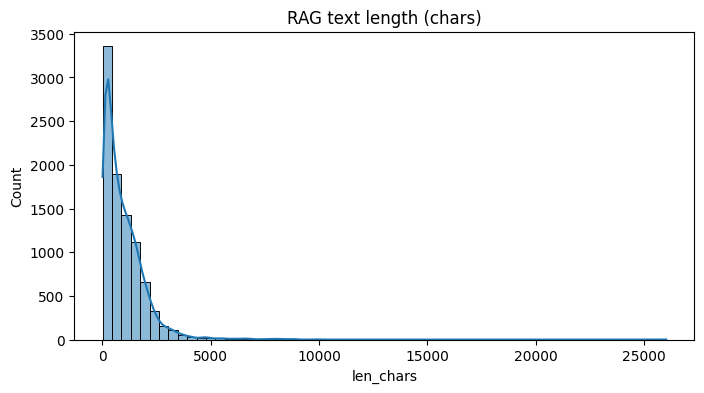

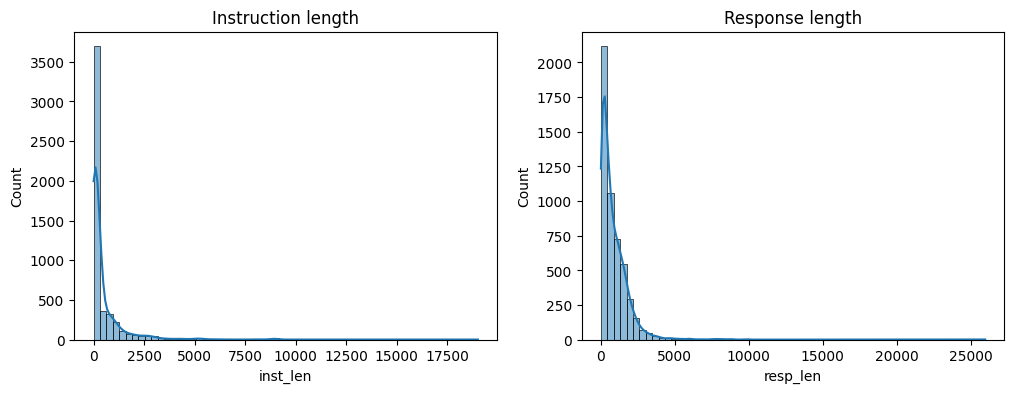

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(rag["len_chars"], bins=60, kde=True)
plt.title("RAG text length (chars)")
plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(sft["inst_len"], bins=60, kde=True, ax=ax[0]); ax[0].set_title("Instruction length")
sns.histplot(sft["resp_len"], bins=60, kde=True, ax=ax[1]); ax[1].set_title("Response length")
plt.show()


In [11]:
OUT_DIR = Path("data/eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
def non_ascii_ratio(t):
    if not t: return 0.0
    non_ascii = sum(1 for ch in t if ord(ch) > 127)
    return non_ascii / max(len(t), 1)

noise_pat = re.compile(r"(http[s]?://|<[^>]+>|\\bN/A\\b|\\blorem ipsum\\b)", re.I)

rag_non_ascii = rag["full_text"].map(non_ascii_ratio)
sft_non_ascii = (sft["instruction"] + " " + sft["response"]).map(non_ascii_ratio)

rag_noise = rag["full_text"].str.contains(noise_pat, regex=True, na=False)
sft_noise = (sft["instruction"] + " " + sft["response"]).str.contains(noise_pat, regex=True, na=False)

quality = {
    "rag_rows": int(len(rag)),
    "sft_rows": int(len(sft)),
    "rag_non_ascii_gt_30pct": int((rag_non_ascii > 0.30).sum()),
    "sft_non_ascii_gt_30pct": int((sft_non_ascii > 0.30).sum()),
    "rag_noise_rows": int(rag_noise.sum()),
    "sft_noise_rows": int(sft_noise.sum()),
    "rag_source_counts": rag["source"].value_counts(dropna=False).to_dict() if "source" in rag.columns else {},
    "sft_source_counts": sft["source"].value_counts(dropna=False).to_dict() if "source" in sft.columns else {}
}

(OUT_DIR / "quality_v1.json").write_text(json.dumps(quality, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(quality, ensure_ascii=False, indent=2))

/tmp/ipykernel_1011/3496236135.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  rag_noise = rag["full_text"].str.contains(noise_pat, regex=True, na=False)


{
  "rag_rows": 9235,
  "sft_rows": 5095,
  "rag_non_ascii_gt_30pct": 310,
  "sft_non_ascii_gt_30pct": 199,
  "rag_noise_rows": 756,
  "sft_noise_rows": 372,
  "rag_source_counts": {
    "openassistant": 7690,
    "dolly": 1545
  },
  "sft_source_counts": {
    "openassistant": 3149,
    "dolly": 1946
  }
}


/tmp/ipykernel_1011/3496236135.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sft_noise = (sft["instruction"] + " " + sft["response"]).str.contains(noise_pat, regex=True, na=False)


In [13]:
def normalize_text(x):
    x = str(x).lower()
    x = re.sub(r"\s+"," ",x).strip()
    return x

def ngrams(text, n=3):
    t = normalize_text(text)
    if len(t) < n:
        return [t] if t else []
    return [t[i:i+n] for i in range(len(t)-n+1)]

def simhash(text, nbits=64):
    v = np.zeros(nbits, dtype=np.int32)
    for g in ngrams(text, 3):
        h = int(hashlib.md5(g.encode("utf-8")).hexdigest(), 16)
        for i in range(nbits):
            v[i] += 1 if ((h >> i) & 1) else -1
    out = 0
    for i in range(nbits):
        if v[i] > 0:
            out |= (1 << i)
    return out

def hamming(a,b):
    return (a ^ b).bit_count()

rag_sample = rag["full_text"].sample(min(3000, len(rag)), random_state=42).tolist()
hashes = [simhash(t) for t in rag_sample]

pairs = 0
near_dup = 0
step = 40

for i in range(len(hashes)):
    for j in range(i+1, min(i+1+step, len(hashes))):
        pairs += 1
        if hamming(hashes[i], hashes[j]) <= 3:
            near_dup += 1

near_dup_rate_est = near_dup / max(pairs, 1)
near_dup_report = {
    "pairs_checked": int(pairs),
    "near_dup_pairs": int(near_dup),
    "near_dup_rate_est": float(near_dup_rate_est)
}

(Path("data/eda") / "near_dup_report.json").write_text(
    json.dumps(near_dup_report, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print(json.dumps(near_dup_report, ensure_ascii=False, indent=2))

{
  "pairs_checked": 119180,
  "near_dup_pairs": 0,
  "near_dup_rate_est": 0.0
}


In [14]:
q = json.loads((OUT_DIR / "quality_v1.json").read_text(encoding="utf-8"))
n = json.loads((OUT_DIR / "near_dup_report.json").read_text(encoding="utf-8"))

In [15]:
gates = {
    "noise_ok": (q["rag_noise_rows"] / max(q["rag_rows"],1) < 0.05) and (q["sft_noise_rows"] / max(q["sft_rows"],1) < 0.05),
    "language_ok": (q["rag_non_ascii_gt_30pct"] / max(q["rag_rows"],1) < 0.20) and (q["sft_non_ascii_gt_30pct"] / max(q["sft_rows"],1) < 0.20),
    "near_dup_ok": n["near_dup_rate_est"] < 0.02,
    "source_balance_present": len(q["rag_source_counts"]) > 0 and len(q["sft_source_counts"]) > 0
}

status = "PASS" if all(gates.values()) else "PASS_WITH_CLEANING_REQUIRED"

final = {
    "eda_status": status,
    "quality": q,
    "near_dup": n,
    "gates": gates,
    "next_step": "build processed_v2_clean with filtering + dedup + reindex"
}

(OUT_DIR / "eda_report_final.json").write_text(json.dumps(final, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(final, ensure_ascii=False, indent=2))

{
  "eda_status": "PASS_WITH_CLEANING_REQUIRED",
  "quality": {
    "rag_rows": 9235,
    "sft_rows": 5095,
    "rag_non_ascii_gt_30pct": 310,
    "sft_non_ascii_gt_30pct": 199,
    "rag_noise_rows": 756,
    "sft_noise_rows": 372,
    "rag_source_counts": {
      "openassistant": 7690,
      "dolly": 1545
    },
    "sft_source_counts": {
      "openassistant": 3149,
      "dolly": 1946
    }
  },
  "near_dup": {
    "pairs_checked": 119180,
    "near_dup_pairs": 0,
    "near_dup_rate_est": 0.0
  },
  "gates": {
    "noise_ok": false,
    "language_ok": true,
    "near_dup_ok": true,
    "source_balance_present": true
  },
  "next_step": "build processed_v2_clean with filtering + dedup + reindex"
}
